### **Notebook 1: Data Loading & Exploratory Data Analysis (EDA)**

**Goal:**

- Load raw Uber trip data

- Understand trip trends across bases and time

- Identify seasonality, peaks, and anomalies

**Objective:**

Build a strong understanding of Uber trip behavior before modeling.

In [ ]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid")

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (12,5)

In [ ]:
# load raw csv from colab path
df = pd.read_csv('/content/Uber-Jan-Feb-FOIL.csv')
df.head(10)

,dispatching_base_number,date,active_vehicles,trips
0,B02512,1/1/2015,190,1132
1,B02765,1/1/2015,225,1765
2,B02764,1/1/2015,3427,29421
3,B02682,1/1/2015,945,7679
4,B02617,1/1/2015,1228,9537
5,B02598,1/1/2015,870,6903
6,B02598,1/2/2015,785,4768
7,B02617,1/2/2015,1137,7065
8,B02512,1/2/2015,175,875
9,B02682,1/2/2015,890,5506


In [ ]:
# check shape, dtypes, and nulls
print("Shape:", df.shape)
display(df.dtypes)
display(df.isnull().sum())

Shape: (354, 4)


,0
dispatching_base_number,object
date,object
active_vehicles,int64
trips,int64


,0
dispatching_base_number,0
date,0
active_vehicles,0
trips,0


**INSIGHT:** No missing values → dataset is clean.

In [ ]:
# check unique bases and sample raw dates
print("Unique bases:", df['dispatching_base_number'].nunique())
display(df['dispatching_base_number'].value_counts().head())
display(df['date'].sample(10))

Unique bases: 6


,count
dispatching_base_number,
B02512,59
B02765,59
B02764,59
B02682,59
B02617,59


,date
112,1/19/2015
319,2/23/2015
262,2/13/2015
81,1/14/2015
298,2/19/2015
315,2/22/2015
279,2/16/2015
201,2/3/2015
241,2/10/2015
326,2/24/2015


**INSIGHT:** Each base has similar counts → balanced dataset.

In [ ]:
# Convert the date column to datetime; handle M/D/YYYY format like '1/1/2015'
df['trip_date'] = pd.to_datetime(df['date'], format='%m/%d/%Y', errors='coerce')

# Check conversions
display(df[['date','trip_date']].head(10))
print("Nulls in trip_date:", df['trip_date'].isnull().sum())

,date,trip_date
0,1/1/2015,2015-01-01
1,1/1/2015,2015-01-01
2,1/1/2015,2015-01-01
3,1/1/2015,2015-01-01
4,1/1/2015,2015-01-01
5,1/1/2015,2015-01-01
6,1/2/2015,2015-01-02
7,1/2/2015,2015-01-02
8,1/2/2015,2015-01-02
9,1/2/2015,2015-01-02


Nulls in trip_date: 0


In [ ]:
# basic statistics for numeric columns
display(df[['active_vehicles','trips']].describe().T)
display(df[['active_vehicles','trips']].isnull().sum())

,count,mean,std,min,25%,50%,75%,max
active_vehicles,354.0,1307.435028,1162.510626,112.0,296.75,1077.0,1417.00,4395.0
trips,354.0,11667.316384,10648.284865,629.0,2408.50,9601.0,13711.25,45858.0


,0
active_vehicles,0
trips,0


In [ ]:
# check duplicate rows by base and date
dupes = df.duplicated(subset=['dispatching_base_number','trip_date']).sum()
print("Duplicate base + date rows:", dupes)

Duplicate base + date rows: 0


In [ ]:
# aggregate citywide trips per day
daily = df.groupby('trip_date', as_index=False)['trips'].sum().sort_values('trip_date')
display(daily.head(10))
display(daily.tail(10))

,trip_date,trips
0,2015-01-01,56437
1,2015-01-02,39189
2,2015-01-03,58449
3,2015-01-04,40798
4,2015-01-05,42752
5,2015-01-06,52426
6,2015-01-07,62102
7,2015-01-08,71413
8,2015-01-09,70296
9,2015-01-10,78484


,trip_date,trips
49,2015-02-19,88757
50,2015-02-20,100915
51,2015-02-21,98380
52,2015-02-22,66440
53,2015-02-23,71217
54,2015-02-24,79115
55,2015-02-25,74691
56,2015-02-26,83568
57,2015-02-27,88806
58,2015-02-28,88181


**INSIGHT:** Clear upward trend + weekly pattern.

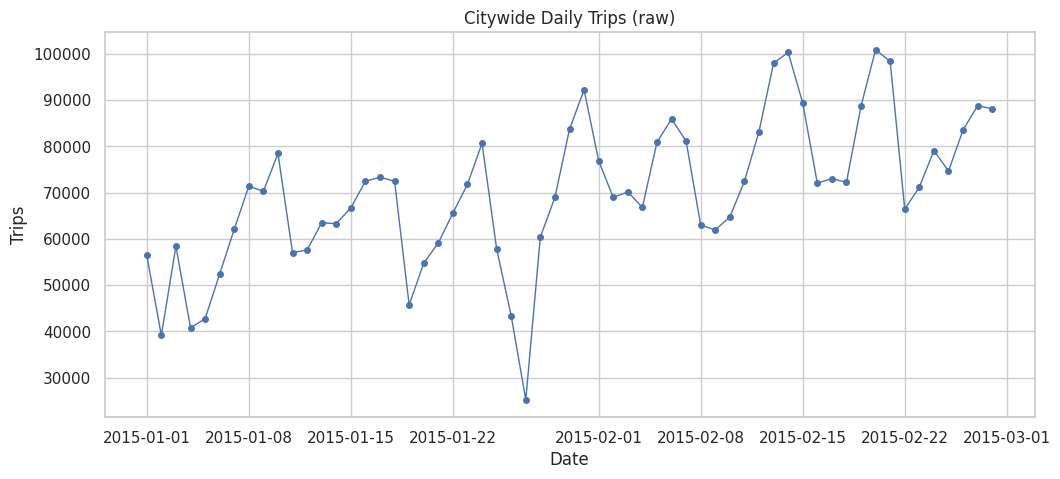

In [ ]:
# plot citywide trip demand over time
plt.plot(daily['trip_date'], daily['trips'], marker='o', markersize=4, linewidth=1)
plt.title('Citywide Daily Trips (raw)')
plt.xlabel('Date')
plt.ylabel('Trips')
plt.show()

**INSIGHT:** Weekly dips visible → includes strong seasonality.

In [ ]:
# total trips per base
base_totals = df.groupby('dispatching_base_number', as_index=False)['trips'].sum().sort_values('trips', ascending=False)
display(base_totals)

,dispatching_base_number,trips
4,B02764,1914449
2,B02617,725025
3,B02682,662509
1,B02598,540791
5,B02765,193670
0,B02512,93786


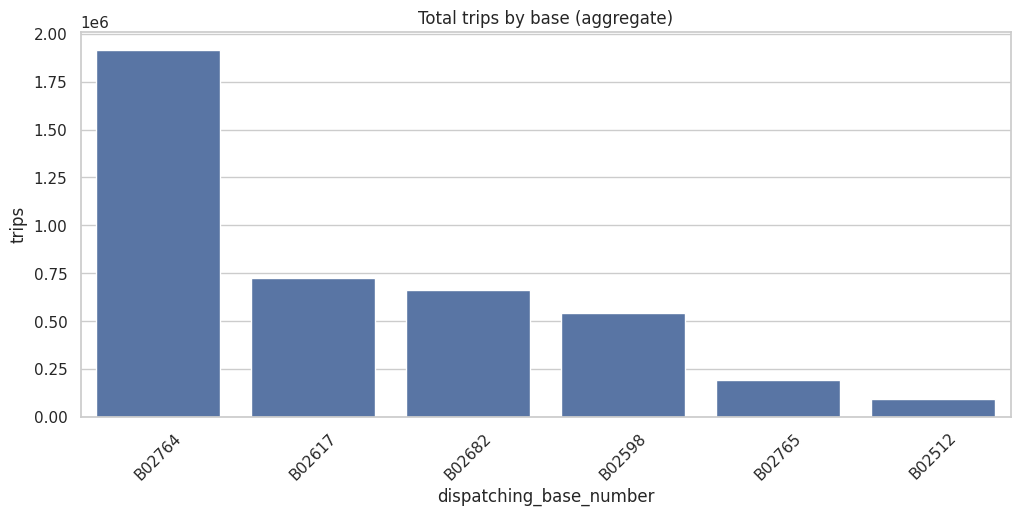

In [ ]:
sns.barplot(data=base_totals, x='dispatching_base_number', y='trips')
plt.title('Total trips by base (aggregate)')
plt.xticks(rotation=45)
plt.show()

**INSIGHT:** One base is significantly larger → base feature will be important.

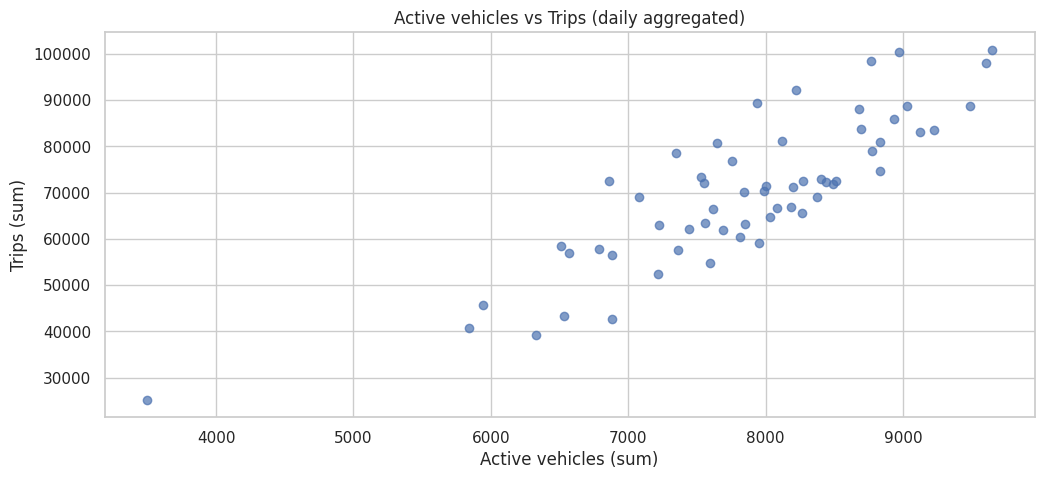

In [ ]:
# scatter: vehicles vs trips aggregated per day
agg_by_date = df.groupby('trip_date', as_index=False).agg({'active_vehicles':'sum','trips':'sum'})
plt.scatter(agg_by_date['active_vehicles'], agg_by_date['trips'], alpha=0.7)
plt.title('Active vehicles vs Trips (daily aggregated)')
plt.xlabel('Active vehicles (sum)')
plt.ylabel('Trips (sum)')
plt.show()

**INSIGHT:** Strong positive relationship → essential predictor for ML.

In [ ]:
# save cleaned file for notebook 2
df.to_csv('uber_raw_with_tripdate.csv', index=False)
print("Saved interim processed file for Notebook 2:", 'uber_raw_with_tripdate.csv')

Saved interim processed file for Notebook 2: uber_raw_with_tripdate.csv


**Summary**

- Explored daily trip trends by dispatching base

- Identified strong weekly and monthly patterns

- Detected demand spikes and drops across dates

- Dataset prepared for feature engineering and modeling

Data ready for forecasting in **Notebook 2**